In [1]:
import pickle as pkl
import pk_plot_library as pplib
import numpy as np
import matplotlib.pyplot as plt
from figrid.data_container import DataContainer
import copy
from scipy.optimize import curve_fit
from scipy.integrate import quad
pplib.imports()
DRAFTPATH = '/Users/cosinga/overleaf/hi_cosmo_apj/figures/'

ds = pkl.load(open('/Users/cosinga/code/hcolor/fig_md_analysis/12-29_pkdatasort.pkl', 'rb'))

ds.tickArgs(direction = 'in', labelsize = 14)
ds.legendArgs(frameon = False, loc = 'upper right', fontsize = 12, slc = (-1, -1))

ds.rowLabelArgs(pos = [0.05, 0.05], fontsize = 16, ha = 'left', va = 'bottom')
ds.colLabelArgs(pos = [0.5, 0.95], fontsize = 16, ha = 'center', va = 'top')

ds.axisArgs(xscale = 'log', yscale = 'log', xlim = [0.04, 10])
ds.axisLabelArgs('both', fontsize = 16)
ds.setOrder('space', ['real', 'redshift', 'rsd'])
ds.setOrder('snapshot', [99, 67, 50])

ds.displayAs('space', ['real', 'redshift', 'rsd'], ['Real Space', 'Redshift Space', 'Redshift Space\nDistortions'])
ds.displayAs('HI_fieldname', ['hisubhalo', 'vn', 'hiptl'], ['Galaxy Centers', 'All Particles', 'Particles in Galaxies'])
ds.displayAs('snapshot', [99, 67, 50], ['z = 0.0', 'z = 0.5', 'z = 1.0'])
ds.displayAs('color', ['red', 'blue', 'resolved', 'ratio'],
            ['HI $\\times$ Red\nCross-Power', 'HI $\\times$ Blue\nCross-Power',
            'HI $\\times$ Galaxy\nCross-Power', r'Color Ratio'])
ds.displayAs('post_process', ['corr_coef', 'theory_bias', 'obs_bias'], 
             ['r', '$b_{\\mathrm{th}}$', '$b_{\\mathrm{obs}}$'])

ds.setColors('post_process', ['pink', 'lime', 'cyan'], ['corr_coef', 'theory_bias', 'obs_bias'])
ds.setColors('color', ['red', 'blue', 'gray'], ['red', 'blue', 'resolved'])
ds.setColors('space', ['green', 'orange'], ['real', 'redshift'])
ds.setColors('HI_fieldname', ['firebrick', 'saddlebrown', 'sandybrown'], ['vn', 'hiptl', 'hisubhalo'])
snapshots = ds.getAttrVals('snapshot')
snapshots.sort()
snapshots.reverse()
ds.setColors('snapshot', 'viridis', snapshots)

ds.setXLabel(pplib.wnum())

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')
def kaiser(z, bias):
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    beta = f / bias
    return (1 + 2/3 * beta + 1/5 * beta**2)
def kaiserX(z, bias1, bias2, cc):
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    kaiser = (1 + 1/3 * (f / bias1 + f / bias2)/cc + 1/5 * f**2 / bias1 / bias2 / cc)
    boost = kaiser
    return boost
def Plin(k, z):
    return cosmo.matterPowerSpectrum(k, z)

In [2]:
def calc_obs_bias(ip):
    ptlip = {'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':ip['path'], 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':ip['snapshot'],
            'space':ip['space']}
    ptl_auto = ds.getMatching(ptlip)
    if len(ptl_auto) > 1:
        print('found too many particles')
        for i in ptl_auto:
            print(i.attrs)
    
    ptl_auto = ptl_auto[0]
    
    auto = ds.getMatching(ip)
    biases = []
    for i in range(len(auto)):
        
        data = [auto[i].data[0], np.sqrt(auto[i].data[1] / ptl_auto.data[1])]
        dc = DataContainer(data)
        dc.update(copy.deepcopy(auto[i].attrs))
        dc.add('post_process','obs_bias')
        dc.add('is_auto', False)
        dc.add('denominator', 'ptl')
        dc.add('_post_time', 'now')

        biases.append(dc)
    return biases

def calc_th_bias(ip):
    ptlip = {'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':ip['path'], 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':ip['snapshot'],
            'space':ip['space']}
    ptl_auto = ds.getMatching(ptlip)
    if len(ptl_auto) > 1:
        print('found too many particles')
        for i in ptl_auto:
            print(i.attrs)
    
    ptl_auto = ptl_auto[0]
    
    cross = ds.getMatching(ip)
    biases = []
    for i in range(len(cross)):
        
        data = [cross[i].data[0], cross[i].data[1] / ptl_auto.data[1]]
        dc = DataContainer(data)
        dc.update(copy.deepcopy(cross[i].attrs))
        dc.add('post_process','theory_bias')
        dc.add('denominator', 'ptl')
        dc.add('_post_time', 'now')
        biases.append(dc)
    return biases
def save_bias(biases):
    SAVE_ATTRS = ['simname', 'snapshot', 'space', 'post_process', 'color', 'model']
    bvals = []
    for bias in biases:
        bval = bias.getData()[1][1]
        attrs = [bias.get(attr) for attr in SAVE_ATTRS]
        bvals.append([bval, attrs])
    return bvals


In [3]:
simnames = ['tng100', 'tng300']
snapshots = [50, 67, 99]
spaces = ['real', 'redshift']
bvals = []
for name in simnames:
    for snap in snapshots:
        for space in spaces:
            
            print("\n", name, snap, space)
            hiip = {'is_auto':True, "HI_fieldname":['vn', 'hiptl'],      
              'axis':0, 'grid_resolution':800, 'simname': name,
              'mas':'CICW', 'snapshot':snap, 'space':space,
             'path':'fiducial', 'post_process':'no key found'}
            obs_biases = calc_obs_bias(hiip)
            print('hi biases:', len(obs_biases))
            ds.extend(obs_biases)
            bvals.extend(save_bias(obs_biases))
            galip = {'gal_res':'diemer',
                      'gal_species':'stmass', 'sim_resolution':'high', 
                     'axis':0, 'grid_resolution':800,
                      'censat':['no key found', 'both'], 'mas':'CICW', 
                     'color': ['blue', 'red', 'resolved'], 'fieldname':'galaxy',
                     'path':'fiducial', 'simname':name, 'space':space,
                    'snapshot':snap, 'post_process':'no key found'}
            obs_biases = calc_obs_bias(galip)
            print('galaxy biases:', len(obs_biases))
            bvals.extend(save_bias(obs_biases))
            ds.extend(obs_biases)


 tng100 50 real
hi biases: 5
galaxy biases: 3

 tng100 50 redshift
hi biases: 5
galaxy biases: 3

 tng100 67 real
hi biases: 5
galaxy biases: 3

 tng100 67 redshift
hi biases: 5
galaxy biases: 3

 tng100 99 real
hi biases: 5
galaxy biases: 3

 tng100 99 redshift
hi biases: 5
galaxy biases: 3

 tng300 50 real
hi biases: 5
galaxy biases: 3

 tng300 50 redshift
hi biases: 5
galaxy biases: 3

 tng300 67 real
hi biases: 5
galaxy biases: 3

 tng300 67 redshift
hi biases: 5
galaxy biases: 3

 tng300 99 real
hi biases: 5
galaxy biases: 3

 tng300 99 redshift
hi biases: 5
galaxy biases: 3


In [4]:
ip = {'is_auto':False, 'HI_fieldname':['vn','hiptl'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[99, 67, 50], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW',
     'color':['blue', 'red', 'resolved'], 'space':['redshift']}
ptlpk = ds.getMatching({'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':'fiducial', 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':99,
            'space':'real'})
ptlk99 = ptlpk[0].getData()[0]
pklin99 = Plin(ptlk99, 0)
ptlpk99 = ptlpk[0].getData()[1]
ptlpk = ds.getMatching({'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':'fiducial', 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':67,
            'space':'real'})
ptlk67 = ptlpk[0].getData()[0]
ptlpk67 = ptlpk[0].getData()[1]
pklin67 = Plin(ptlk99, ptlpk[0].get('redshift'))
ptlpk = ds.getMatching({'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':'fiducial', 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':50,
            'space':'real'})
ptlk50 = ptlpk[0].getData()[0]
ptlpk50 = ptlpk[0].getData()[1]
pklin50 = Plin(ptlk99, ptlpk[0].get('redshift'))

In [5]:
bhi = [0.77, 1.02, 1.3]
bblue = [0.93, 1.31, 1.73]
bred = [1.66, 2.1, 2.61]
bgal = [1.47, 1.71, 2.04]
ccred = [0.92] * 3
ccblue = [0.99] * 3
ccgal = [0.94, 0.96, 0.97]
biases = [bblue, bred, bgal]
ccs = [ccblue, ccred, ccgal]
sigblue = [2.30, 2.85, 2.09]
sigred = [3.52, 2.82, 1.97]
siggal = [3.42, 2.97, 2.22]
sigmas = [sigblue, sigred, siggal]
sighi = [2.39, 3.06, 2.66]
ptlpks = [(ptlk99, ptlpk99), (ptlk67, ptlpk67), (ptlk50, ptlpk50)]
redshifts = [0, 0.5, 1]
snapshots = [99, 67, 50]
omegahis = [7.4e-4, 6.663e-4, 6e-4]
color_idxs = ['blue', 'red', 'resolved']
nmodes = pkl.load(open('nmodes.pkl', 'rb'))
kmin = [0.03]
kmax = [0.1, 0.3, 0.5, 1, 2, 5, 10]

thi_dict = {}
k_dict = {}
cov_dict = {}

def omegam(snap):
    a = 1 / (1 + redshifts[snap])
    om0 = 0.3089 # from TNG website
    oml = 0.6911 # from TNG website
    return om0 * a**-3 / (oml + om0 * a**-3)

def thi(omegahi, snap):
    h = 0.6774
    om = omegam(snap); oml = 0.6911
    return 180 * omegahi * h * (1 + redshifts[snap])**2 / (om * (1 + redshifts[snap])**3 + oml)**0.5

def omegahi(thi, snap):
    h = 0.6774
    om = omegam(snap); oml = 0.6911
    return thi / 180 / h / (1 + redshifts[snap])**2 * np.sqrt(om * (1 + redshifts[snap])**3 + oml)

def get_key(model, color, snap):
    return '%s_%s_%d'%(model, color, snap)

def key_to_vals(key):
    splt = key.split('_')
    return splt[0], splt[1], int(splt[2])

def print_ohi(_thi_dict):
    for k, v in _thi_dict.items():
        print(k)
        model, color, snap = key_to_vals(k)
        snap_idx = snapshots.index(snap)
        omegas = omegahi(np.array(v), snap_idx)
        
        print(omegas)
        print('\n')
    return
GALCOUNTS = dict(
    red_50 = 22495,
    blue_50 = 158408,
    resolved_50 = 180903,
    red_67 = 44041,
    blue_67 = 155875,
    resolved_67 = 199916,
    red_99 = 83597,
    blue_99 = 121755,
    resolved_99 = 20532
)

def get_uncert(kmask, pk, thi_snap, ip, color):
    hiip = copy.deepcopy(ip)
    galip = copy.deepcopy(ip)
    galip['color'] = color; galip['is_auto'] = True
    hiip['is_auto'] = True
    del galip['HI_fieldname']
    del hiip['color_cut']; del hiip['gal_res']; del hiip['gal_species']; del hiip['color']

    hi_auto = ds.getMatching(hiip)
    gal_auto = ds.getMatching(galip)
    if len(hi_auto) > 1:
        raise ValueError('too many hi results')
    else:
        hi_auto = hi_auto[0].getData()[1]
    if len(gal_auto) > 1:
        raise ValueError('too many gal results')
    else:
        gal_auto = gal_auto[0].getData()[1]
    
    sigma = np.sqrt(1 / 2 / nmodes[kmask])
    pk_term = np.sqrt((pk * thi_snap)**2 + hi_auto[kmask] * thi_snap**2 * (gal_auto[kmask] + 1/GALCOUNTS['%s_%d'%(color, ip['snapshot'][0])]))
    return sigma * pk_term
    
# def get_hi_auto_uncert(kmask, pk, snap):
#     sig = np.sqrt(2 / nmodes[kmask]) * pk
#     return sig

# def get_xpk_uncert(kmask, xpk, hi_auto, gal_auto, snap):
#     sig_stat = 

In [6]:
def plot_ohi_basic(_thi_dict, _cov_dict):
    ncols = 3
    nrows = len(_thi_dict.keys()) // 3
    fig, axes = plt.subplots(nrows, ncols, figsize = (3 * ncols + 2, 3 * nrows + 1), sharey = True)
    axes = np.ravel(axes)
    ax_idx = 0
    for k, v in _thi_dict.items():
        model, color, snap = key_to_vals(k)
        snap_idx = snapshots.index(snap)
        omegas = omegahi(np.array(v), snap_idx)
        actual = omegahis[snap_idx]
        
        
        plt.sca(axes[ax_idx])
        plt.title(k)
        ksnap = k_dict[snap]
        keff = []
        yerr = []
#         yerr = [[], []]
        for i in range(len(ksnap)):
            keff.append(np.sum(ksnap[i]) / len(ksnap[i]))
            uncert_thi = np.sqrt(np.diag(_cov_dict[k][i]))[0][0]
            yerr.append(omegahi(uncert_thi, snap_idx))
#             lower = omegahi(v[i] - uncert_thi, snap_idx)
#             upper = omegahi(v[i] + uncert_thi, snap_idx)
#             yerr[0].append(lower - omegas[i])
#             yerr[1].append(upper - omegas[i])
#         print(yerr)
        plt.errorbar(keff, omegas, yerr = yerr, fmt = 'bo')
        plt.plot(keff, [actual]*len(keff), color = 'black')
        plt.xscale('log')
        ax_idx += 1
    plt.ylim(0, 0.0008)
    return fig, axes

In [7]:
# model A definitions, snapshot 50

def A_50_blue(k, C):
    snap = 50; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def A_50_red(k, C):
    snap = 50; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def A_50_resolved(k, C):
    snap = 50; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C


A_blue_50
[0.00047546 0.00044707 0.00040234 0.00026489 0.00016815 0.0001339
 0.00015868]


A_red_50
[4.57459478e-04 4.24648212e-04 3.70834579e-04 2.11304040e-04
 1.07333341e-04 6.91794394e-05 6.89344122e-05]


A_resolved_50
[0.00046657 0.00043607 0.00038625 0.00023558 0.00013682 0.0001028
 0.00011641]




(<Figure size 792x288 with 3 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>], dtype=object))

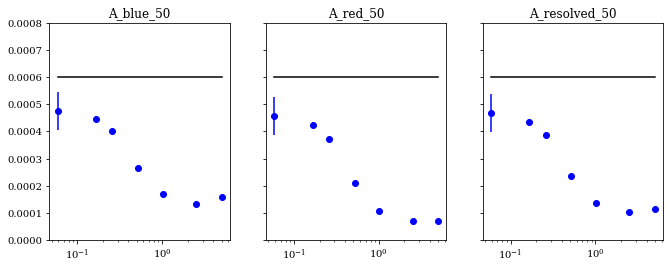

In [8]:
# getting model A values, snapshot 50
model = 'A'
snap = 50; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()


k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata, thi_snap, ip, 'blue')
            val, cov = curve_fit(A_50_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata , thi_snap, ip, 'red')
            val, cov = curve_fit(A_50_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata , thi_snap, ip, 'resolved')
            val, cov = curve_fit(A_50_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [ ]:
# model B definitions, snapshot 50

def B_50_blue(k, C):
    snap = 50; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def B_50_red(k, C):
    snap = 50; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def B_50_resolved(k, C):
    snap = 50; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C


A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]




(<Figure size 792x504 with 6 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>], dtype=object))

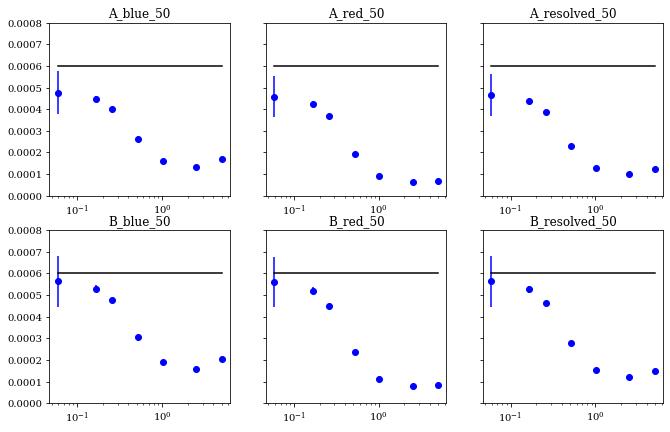

In [10]:
# getting model B values, snapshot 50
model = 'B'
snap = 50; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()

k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(B_50_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(B_50_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(B_50_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [11]:
# model C definitions, snapshot 50
def integrandX(mu, k, real_pk, f, bias1, bias2, cc, sigma1, sigma2):
    kaiser = real_pk * (1 + f*mu**2/cc/bias1 + f*mu**2/cc/bias2 + f**2 * mu**4 / bias1 /bias2 / cc)
    fog = 1/(1 + 0.5 * k**2 * mu**2 * sigma1**2)/(1 + 0.5 * k**2 * mu**2 * sigma2**2)
    return kaiser * fog

def solve_integralX(k, real_pk, z, bias1, bias2, cc, sigma1, sigma2):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrandX, lower_limit, upper_limit, args=(k, real_pk, f, bias1, bias2, cc, sigma1, sigma2)) 
    return result * 0.5



def C_50_blue(k, C):
    snap = 50; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C

def C_50_red(k, C):
    snap = 50; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C

def C_50_resolved(k, C):
    snap = 50; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C



A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]




(<Figure size 792x720 with 9 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>], dtype=object))

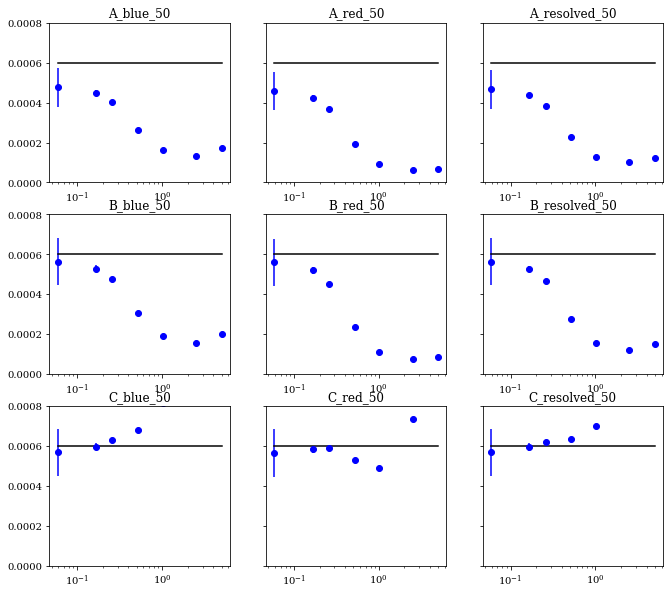

In [12]:
# getting model C values, snapshot 50
model = 'C'
snap = 50; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()

k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)

            val, cov = curve_fit(C_50_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(C_50_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(C_50_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [13]:
# model D definitions, snapshot 50
def integrandX(mu, k, real_pk, f, bias1, bias2, cc, sigma1, sigma2):
    kaiser = real_pk * (1 + f*mu**2/cc/bias1 + f*mu**2/cc/bias2 + f**2 * mu**4 / bias1 /bias2 / cc)
    fog = 1/(1 + 0.5 * k**2 * mu**2 * sigma1**2)/(1 + 0.5 * k**2 * mu**2 * sigma2**2)
    return kaiser * fog

def solve_integralX(k, real_pk, z, bias1, bias2, cc, sigma1, sigma2):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrandX, lower_limit, upper_limit, args=(k, real_pk, f, bias1, bias2, cc, sigma1, sigma2)) 
    return result * 0.5



def D_50_blue(k, C):
    snap = 50; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snap], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, kdep_biashi[i] * kdep_galbias[i] * kdep_cc[i] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C

def D_50_red(k, C):
    snap = 50; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snap], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, kdep_biashi[i] * kdep_galbias[i] * kdep_cc[i] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C
def D_50_resolved(k, C):
    snap = 50; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snap], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, kdep_biashi[i] * kdep_galbias[i] * kdep_cc[i] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C


A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]


D_blue_50
[0.00057068 0.00056845 0.00058289 0.00059297 0.00062029 0.00066378
 0

(<Figure size 792x936 with 12 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>,
        <AxesSubplot:title={'center':'D_blue_50'}>,
        <AxesSubplot:title={'center':'D_red_50'}>,
        <AxesSubplot:title={'center':'D_resolved_50'}>], dtype=object))

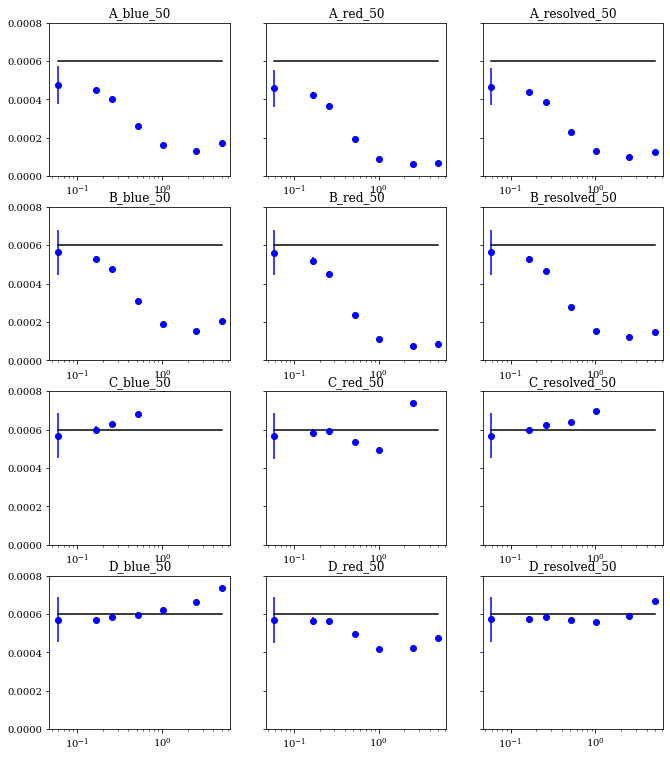

In [14]:
# getting model D values, snapshot 50
model = 'D'
snap = 50; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()

k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)

            val, cov = curve_fit(D_50_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma=uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(D_50_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(D_50_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [15]:
# model A definitions, snapshot 67

def A_67_blue(k, C):
    snap = 67; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def A_67_red(k, C):
    snap = 67; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def A_67_resolved(k, C):
    snap = 67; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C


A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]


D_blue_50
[0.00057068 0.00056845 0.00058289 0.00059297 0.00062029 0.00066378
 0

(<Figure size 792x1152 with 15 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>,
        <AxesSubplot:title={'center':'D_blue_50'}>,
        <AxesSubplot:title={'center':'D_red_50'}>,
        <AxesSubplot:title={'center':'D_resolved_50'}>,
        <AxesSubplot:title={'center':'A_blue_67'}>,
        <AxesSubplot:title={'center':'A_red_67'}>,
        <AxesSubplot:title={'center':'A_resolved_67'}>], dtype=object))

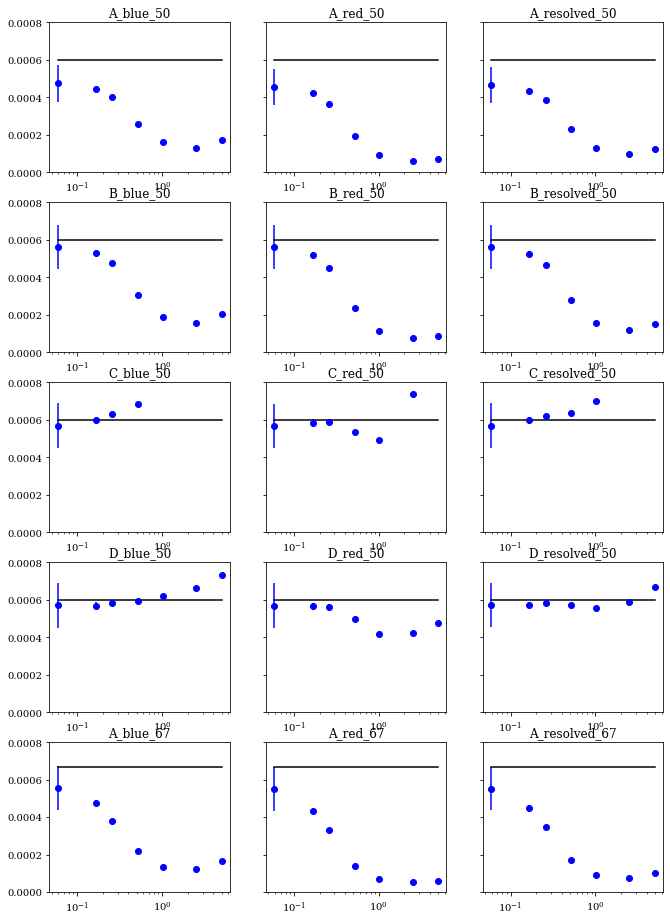

In [16]:
# getting model A values, snapshot 50
model = 'A'
snap = 67; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()


k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(A_67_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(A_67_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(A_67_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [17]:
# model B definitions, snapshot 67

def B_67_blue(k, C):
    snap = 67; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def B_67_red(k, C):
    snap = 67; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def B_67_resolved(k, C):
    snap = 67; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C


A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]


D_blue_50
[0.00057068 0.00056845 0.00058289 0.00059297 0.00062029 0.00066378
 0

(<Figure size 792x1368 with 18 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>,
        <AxesSubplot:title={'center':'D_blue_50'}>,
        <AxesSubplot:title={'center':'D_red_50'}>,
        <AxesSubplot:title={'center':'D_resolved_50'}>,
        <AxesSubplot:title={'center':'A_blue_67'}>,
        <AxesSubplot:title={'center':'A_red_67'}>,
        <AxesSubplot:title={'center':'A_resolved_67'}>,
        <AxesSubplot:title={'center':'B_blue_67'}>,
        <AxesSubplot:title={'center':'B_red_67'}>,
        <AxesSubplot:title={'center':'B_resolved_67'}>], dtype=o

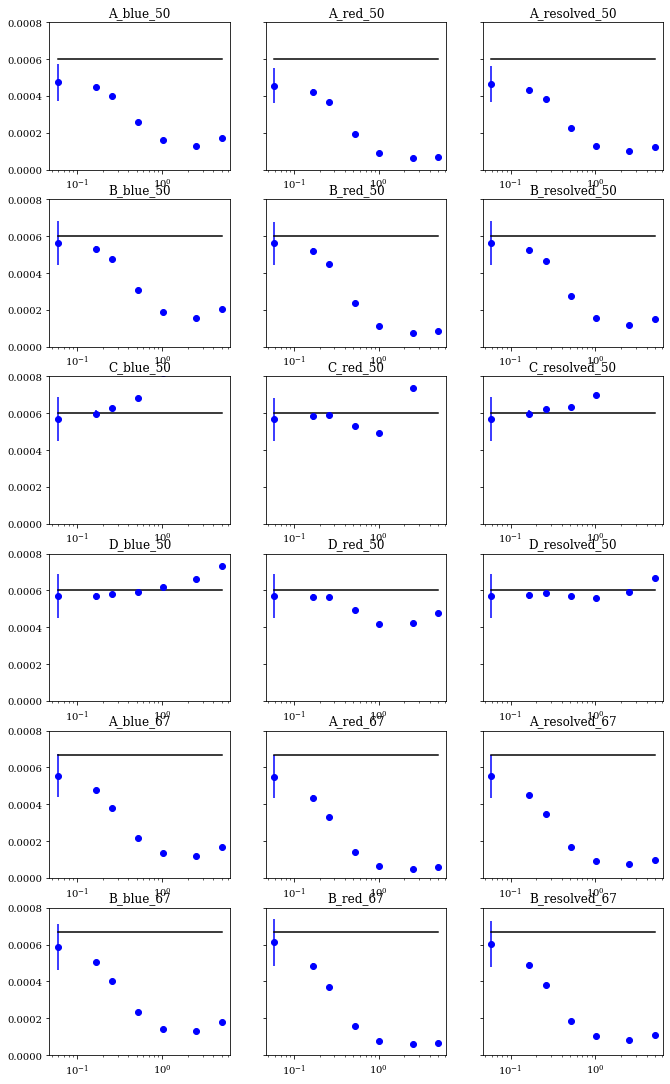

In [18]:
# getting model B values, snapshot 67
model = 'B'
snap = 67; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()

k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(B_67_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(B_67_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(B_67_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [19]:
# model C definitions, snapshot 67
def integrandX(mu, k, real_pk, f, bias1, bias2, cc, sigma1, sigma2):
    kaiser = real_pk * (1 + f*mu**2/cc/bias1 + f*mu**2/cc/bias2 + f**2 * mu**4 / bias1 /bias2 / cc)
    fog = 1/(1 + 0.5 * k**2 * mu**2 * sigma1**2)/(1 + 0.5 * k**2 * mu**2 * sigma2**2)
    return kaiser * fog

def solve_integralX(k, real_pk, z, bias1, bias2, cc, sigma1, sigma2):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrandX, lower_limit, upper_limit, args=(k, real_pk, f, bias1, bias2, cc, sigma1, sigma2)) 
    return result * 0.5



def C_67_blue(k, C):
    snap = 67; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C

def C_67_red(k, C):
    snap = 67; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C

def C_67_resolved(k, C):
    snap = 67; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C



A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]


D_blue_50
[0.00057068 0.00056845 0.00058289 0.00059297 0.00062029 0.00066378
 0

(<Figure size 792x1584 with 21 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>,
        <AxesSubplot:title={'center':'D_blue_50'}>,
        <AxesSubplot:title={'center':'D_red_50'}>,
        <AxesSubplot:title={'center':'D_resolved_50'}>,
        <AxesSubplot:title={'center':'A_blue_67'}>,
        <AxesSubplot:title={'center':'A_red_67'}>,
        <AxesSubplot:title={'center':'A_resolved_67'}>,
        <AxesSubplot:title={'center':'B_blue_67'}>,
        <AxesSubplot:title={'center':'B_red_67'}>,
        <AxesSubplot:title={'center':'B_resolved_67'}>,
        

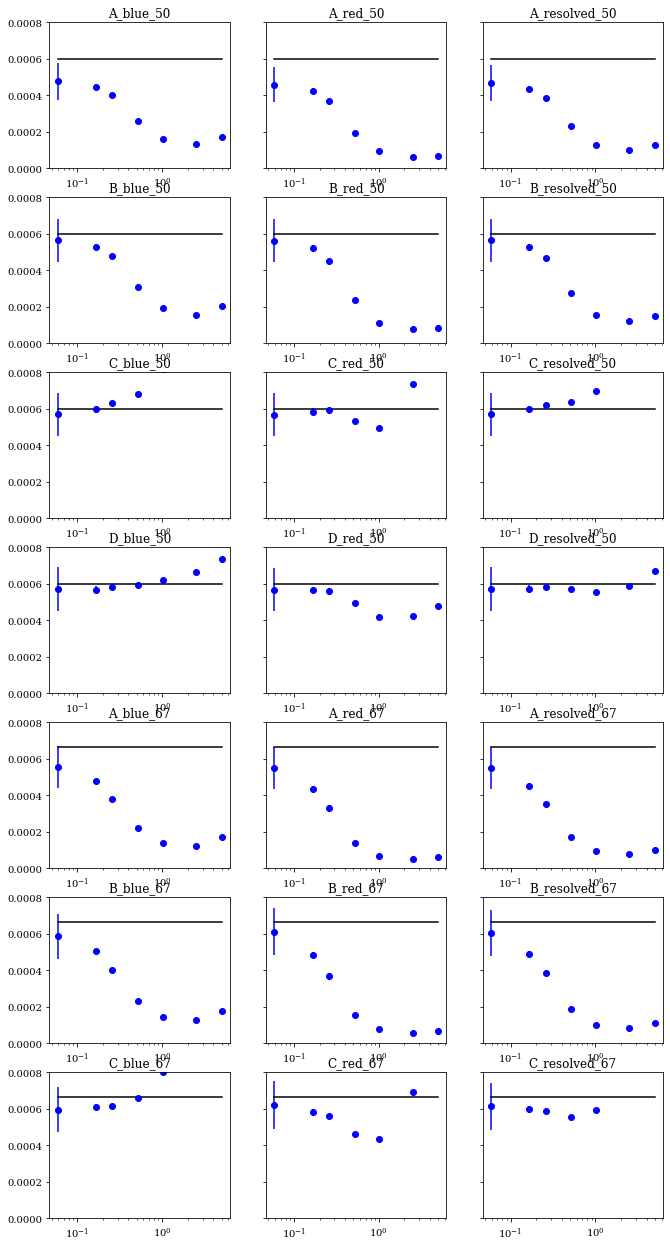

In [20]:
# getting model C values, snapshot 67
model = 'C'
snap = 67; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()

k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(C_67_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(C_67_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(C_67_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [21]:
# model D definitions, snapshot 67
def integrandX(mu, k, real_pk, f, bias1, bias2, cc, sigma1, sigma2):
    kaiser = real_pk * (1 + f*mu**2/cc/bias1 + f*mu**2/cc/bias2 + f**2 * mu**4 / bias1 /bias2 / cc)
    fog = 1/(1 + 0.5 * k**2 * mu**2 * sigma1**2)/(1 + 0.5 * k**2 * mu**2 * sigma2**2)
    return kaiser * fog

def solve_integralX(k, real_pk, z, bias1, bias2, cc, sigma1, sigma2):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrandX, lower_limit, upper_limit, args=(k, real_pk, f, bias1, bias2, cc, sigma1, sigma2)) 
    return result * 0.5



def D_67_blue(k, C):
    snap = 67; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snap], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, kdep_biashi[i] * kdep_galbias[i] * kdep_cc[i] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C

def D_67_red(k, C):
    snap = 67; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snap], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, kdep_biashi[i] * kdep_galbias[i] * kdep_cc[i] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C
def D_67_resolved(k, C):
    snap = 67; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snap], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, kdep_biashi[i] * kdep_galbias[i] * kdep_cc[i] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C


A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]


D_blue_50
[0.00057068 0.00056845 0.00058289 0.00059297 0.00062029 0.00066378
 0

(<Figure size 792x1800 with 24 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>,
        <AxesSubplot:title={'center':'D_blue_50'}>,
        <AxesSubplot:title={'center':'D_red_50'}>,
        <AxesSubplot:title={'center':'D_resolved_50'}>,
        <AxesSubplot:title={'center':'A_blue_67'}>,
        <AxesSubplot:title={'center':'A_red_67'}>,
        <AxesSubplot:title={'center':'A_resolved_67'}>,
        <AxesSubplot:title={'center':'B_blue_67'}>,
        <AxesSubplot:title={'center':'B_red_67'}>,
        <AxesSubplot:title={'center':'B_resolved_67'}>,
        

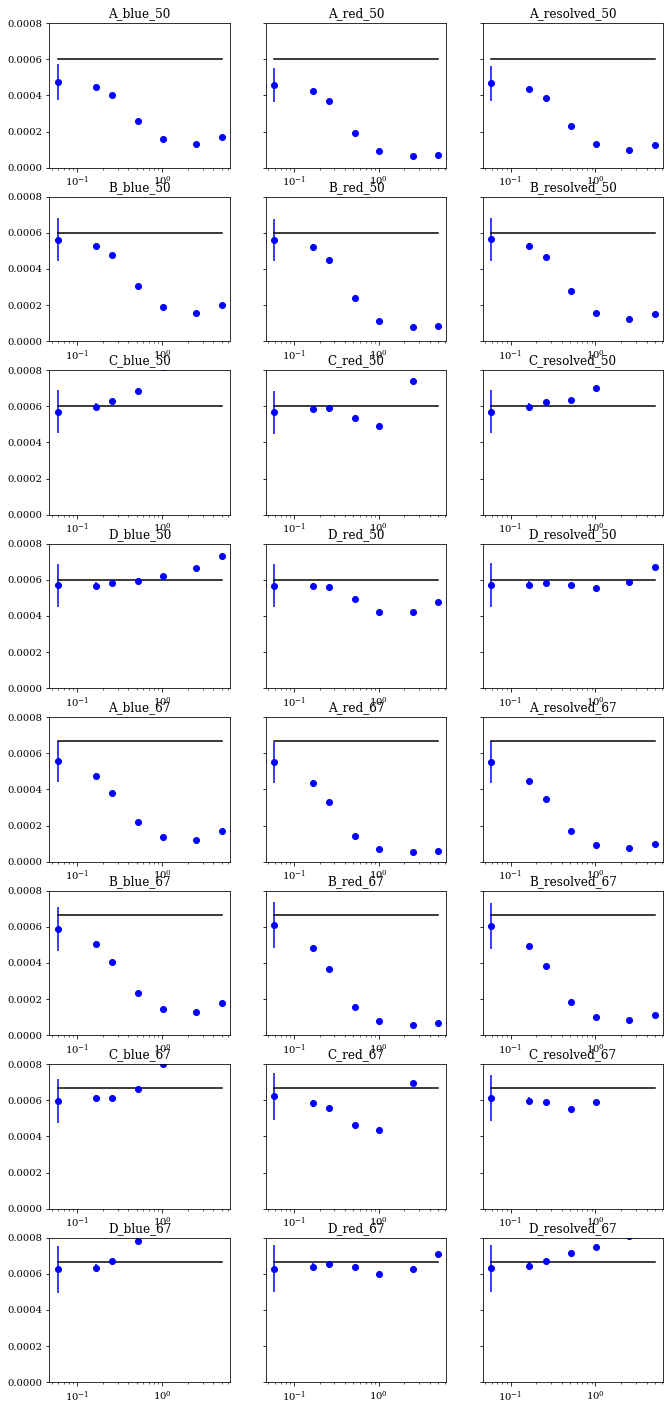

In [22]:
# getting model D values, snapshot 67
model = 'D'
snap = 67; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()

k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(D_67_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(D_67_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(D_67_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [23]:
# model A definitions, snapshot 99

def A_99_blue(k, C):
    snap = 99; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def A_99_red(k, C):
    snap = 99; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def A_99_resolved(k, C):
    snap = 99; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C


A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]


D_blue_50
[0.00057068 0.00056845 0.00058289 0.00059297 0.00062029 0.00066378
 0

(<Figure size 792x2016 with 27 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>,
        <AxesSubplot:title={'center':'D_blue_50'}>,
        <AxesSubplot:title={'center':'D_red_50'}>,
        <AxesSubplot:title={'center':'D_resolved_50'}>,
        <AxesSubplot:title={'center':'A_blue_67'}>,
        <AxesSubplot:title={'center':'A_red_67'}>,
        <AxesSubplot:title={'center':'A_resolved_67'}>,
        <AxesSubplot:title={'center':'B_blue_67'}>,
        <AxesSubplot:title={'center':'B_red_67'}>,
        <AxesSubplot:title={'center':'B_resolved_67'}>,
        

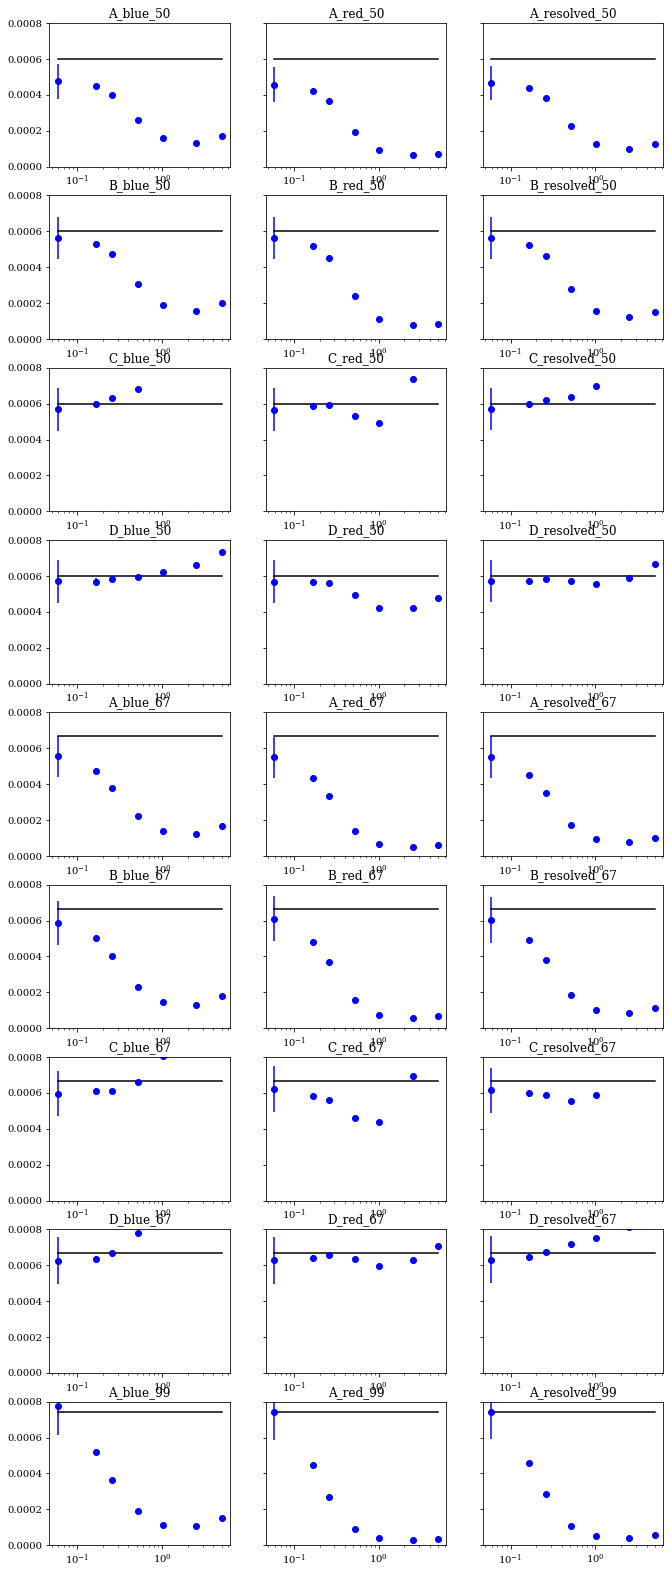

In [24]:
# getting model A values, snapshot 50
model = 'A'
snap = 99; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()


k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(A_99_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(A_99_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(A_99_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [25]:
# model B definitions, snapshot 99

def B_99_blue(k, C):
    snap = 99; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def B_99_red(k, C):
    snap = 99; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def B_99_resolved(k, C):
    snap = 99; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C


A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]


D_blue_50
[0.00057068 0.00056845 0.00058289 0.00059297 0.00062029 0.00066378
 0

(<Figure size 792x2232 with 30 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>,
        <AxesSubplot:title={'center':'D_blue_50'}>,
        <AxesSubplot:title={'center':'D_red_50'}>,
        <AxesSubplot:title={'center':'D_resolved_50'}>,
        <AxesSubplot:title={'center':'A_blue_67'}>,
        <AxesSubplot:title={'center':'A_red_67'}>,
        <AxesSubplot:title={'center':'A_resolved_67'}>,
        <AxesSubplot:title={'center':'B_blue_67'}>,
        <AxesSubplot:title={'center':'B_red_67'}>,
        <AxesSubplot:title={'center':'B_resolved_67'}>,
        

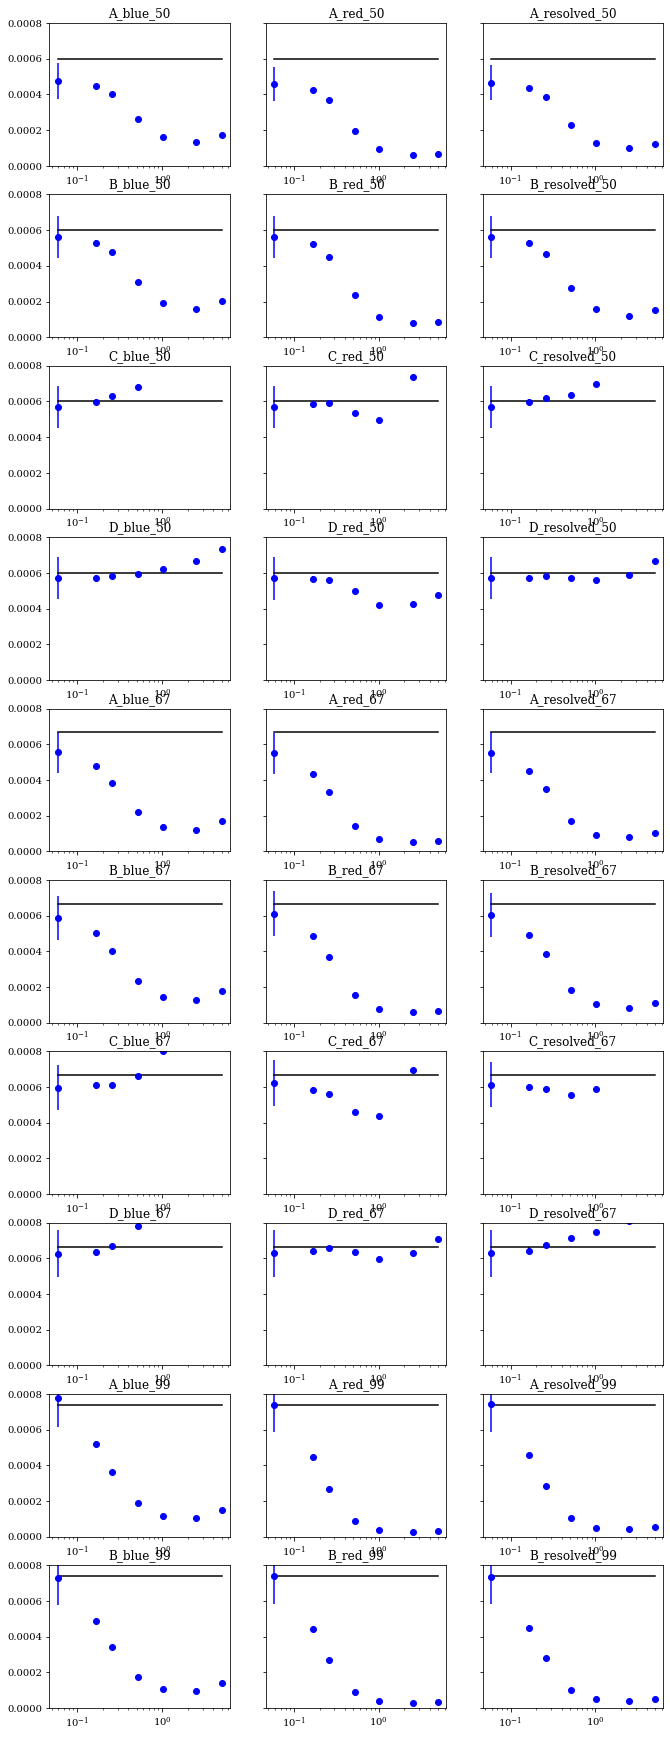

In [26]:
# getting model B values, snapshot 99
model = 'B'
snap = 99; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()

k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(B_99_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(B_99_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(B_99_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [27]:
# model C definitions, snapshot 99
def integrandX(mu, k, real_pk, f, bias1, bias2, cc, sigma1, sigma2):
    kaiser = real_pk * (1 + f*mu**2/cc/bias1 + f*mu**2/cc/bias2 + f**2 * mu**4 / bias1 /bias2 / cc)
    fog = 1/(1 + 0.5 * k**2 * mu**2 * sigma1**2)/(1 + 0.5 * k**2 * mu**2 * sigma2**2)
    return kaiser * fog

def solve_integralX(k, real_pk, z, bias1, bias2, cc, sigma1, sigma2):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrandX, lower_limit, upper_limit, args=(k, real_pk, f, bias1, bias2, cc, sigma1, sigma2)) 
    return result * 0.5



def C_99_blue(k, C):
    snap = 99; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C

def C_99_red(k, C):
    snap = 99; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C

def C_99_resolved(k, C):
    snap = 99; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C



A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]


D_blue_50
[0.00057068 0.00056845 0.00058289 0.00059297 0.00062029 0.00066378
 0

(<Figure size 792x2448 with 33 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>,
        <AxesSubplot:title={'center':'D_blue_50'}>,
        <AxesSubplot:title={'center':'D_red_50'}>,
        <AxesSubplot:title={'center':'D_resolved_50'}>,
        <AxesSubplot:title={'center':'A_blue_67'}>,
        <AxesSubplot:title={'center':'A_red_67'}>,
        <AxesSubplot:title={'center':'A_resolved_67'}>,
        <AxesSubplot:title={'center':'B_blue_67'}>,
        <AxesSubplot:title={'center':'B_red_67'}>,
        <AxesSubplot:title={'center':'B_resolved_67'}>,
        

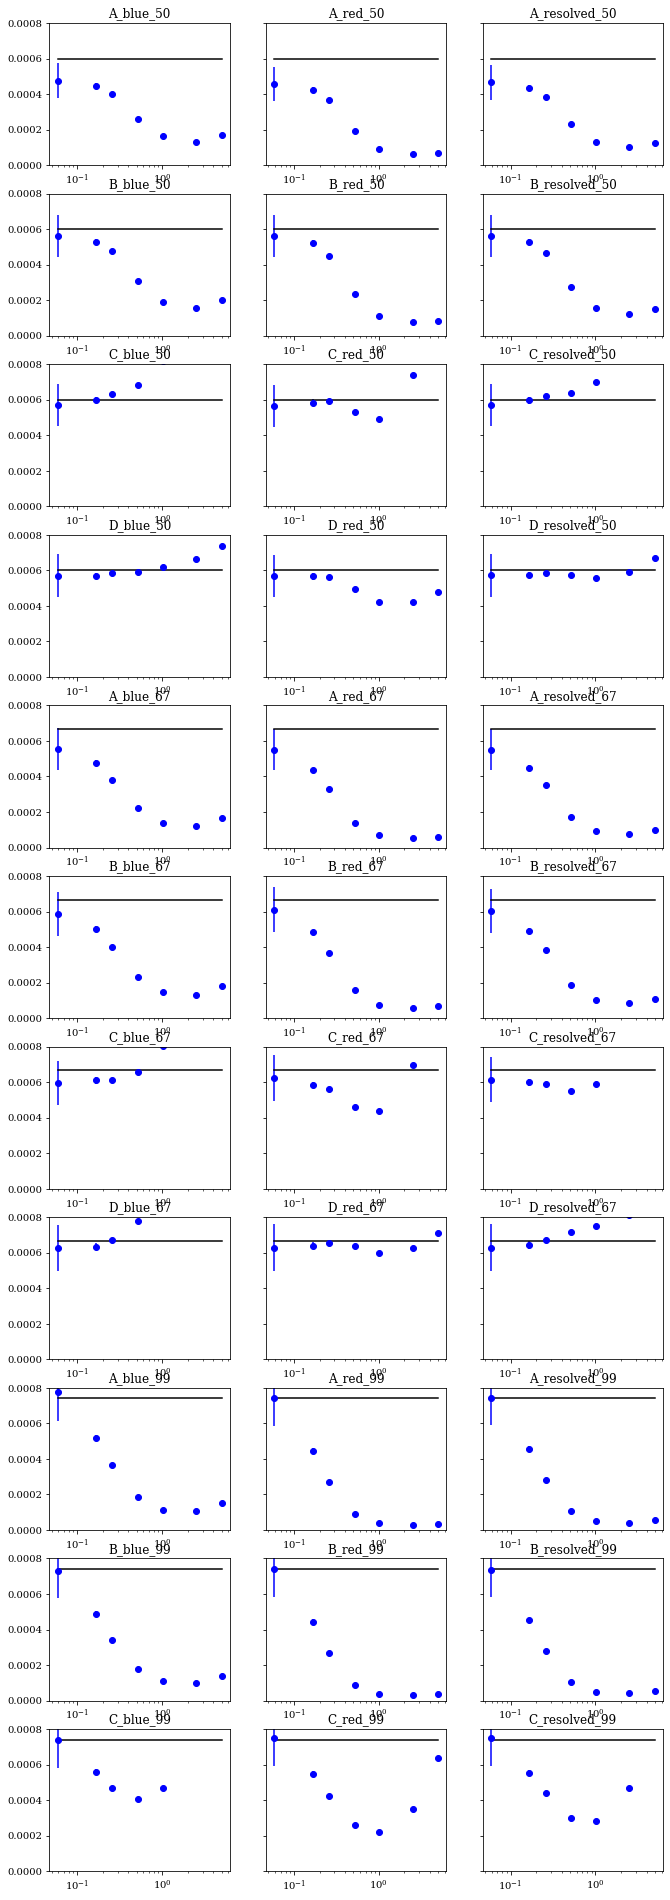

In [28]:
# getting model C values, snapshot 99
model = 'C'
snap = 99; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()

k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(C_99_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(C_99_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(C_99_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [29]:
# model D definitions, snapshot 99
def integrandX(mu, k, real_pk, f, bias1, bias2, cc, sigma1, sigma2):
    kaiser = real_pk * (1 + f*mu**2/cc/bias1 + f*mu**2/cc/bias2 + f**2 * mu**4 / bias1 /bias2 / cc)
    fog = 1/(1 + 0.5 * k**2 * mu**2 * sigma1**2)/(1 + 0.5 * k**2 * mu**2 * sigma2**2)
    return kaiser * fog

def solve_integralX(k, real_pk, z, bias1, bias2, cc, sigma1, sigma2):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrandX, lower_limit, upper_limit, args=(k, real_pk, f, bias1, bias2, cc, sigma1, sigma2)) 
    return result * 0.5



def D_99_blue(k, C):
    snap = 99; color = 'blue'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snap], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, kdep_biashi[i] * kdep_galbias[i] * kdep_cc[i] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C

def D_99_red(k, C):
    snap = 99; color = 'red'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snap], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, kdep_biashi[i] * kdep_galbias[i] * kdep_cc[i] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C
def D_99_resolved(k, C):
    snap = 99; color = 'resolved'
    snap_idx = snapshots.index(snap)
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snap], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, kdep_biashi[i] * kdep_galbias[i] * kdep_cc[i] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
        
    return pk * C


A_blue_50
[0.00047543 0.00044694 0.00040144 0.00026039 0.00016127 0.00013181
 0.00017165]


A_red_50
[4.57470063e-04 4.24066142e-04 3.66905988e-04 1.93220777e-04
 9.16321508e-05 6.34479158e-05 6.89599886e-05]


A_resolved_50
[4.66572356e-04 4.35947795e-04 3.85050575e-04 2.29463186e-04
 1.28954982e-04 9.99976069e-05 1.24550977e-04]


B_blue_50
[0.0005631  0.00052935 0.00047547 0.0003084  0.00019101 0.00015611
 0.0002033 ]


B_red_50
[5.61438499e-04 5.20442926e-04 4.50292083e-04 2.37133730e-04
 1.12457232e-04 7.78676147e-05 8.46324068e-05]


B_resolved_50
[0.00056314 0.00052618 0.00046475 0.00027696 0.00015565 0.00012069
 0.00015033]


C_blue_50
[0.00056898 0.00059801 0.00062947 0.0006837  0.00081876 0.00143917
 0.00273404]


C_red_50
[0.00056696 0.00058417 0.00059101 0.00053335 0.00049382 0.00073754
 0.00132293]


C_resolved_50
[0.00056926 0.00059705 0.00062218 0.0006372  0.00069902 0.00116183
 0.00217744]


D_blue_50
[0.00057068 0.00056845 0.00058289 0.00059297 0.00062029 0.00066378
 0

(<Figure size 792x2664 with 36 Axes>,
 array([<AxesSubplot:title={'center':'A_blue_50'}>,
        <AxesSubplot:title={'center':'A_red_50'}>,
        <AxesSubplot:title={'center':'A_resolved_50'}>,
        <AxesSubplot:title={'center':'B_blue_50'}>,
        <AxesSubplot:title={'center':'B_red_50'}>,
        <AxesSubplot:title={'center':'B_resolved_50'}>,
        <AxesSubplot:title={'center':'C_blue_50'}>,
        <AxesSubplot:title={'center':'C_red_50'}>,
        <AxesSubplot:title={'center':'C_resolved_50'}>,
        <AxesSubplot:title={'center':'D_blue_50'}>,
        <AxesSubplot:title={'center':'D_red_50'}>,
        <AxesSubplot:title={'center':'D_resolved_50'}>,
        <AxesSubplot:title={'center':'A_blue_67'}>,
        <AxesSubplot:title={'center':'A_red_67'}>,
        <AxesSubplot:title={'center':'A_resolved_67'}>,
        <AxesSubplot:title={'center':'B_blue_67'}>,
        <AxesSubplot:title={'center':'B_red_67'}>,
        <AxesSubplot:title={'center':'B_resolved_67'}>,
        

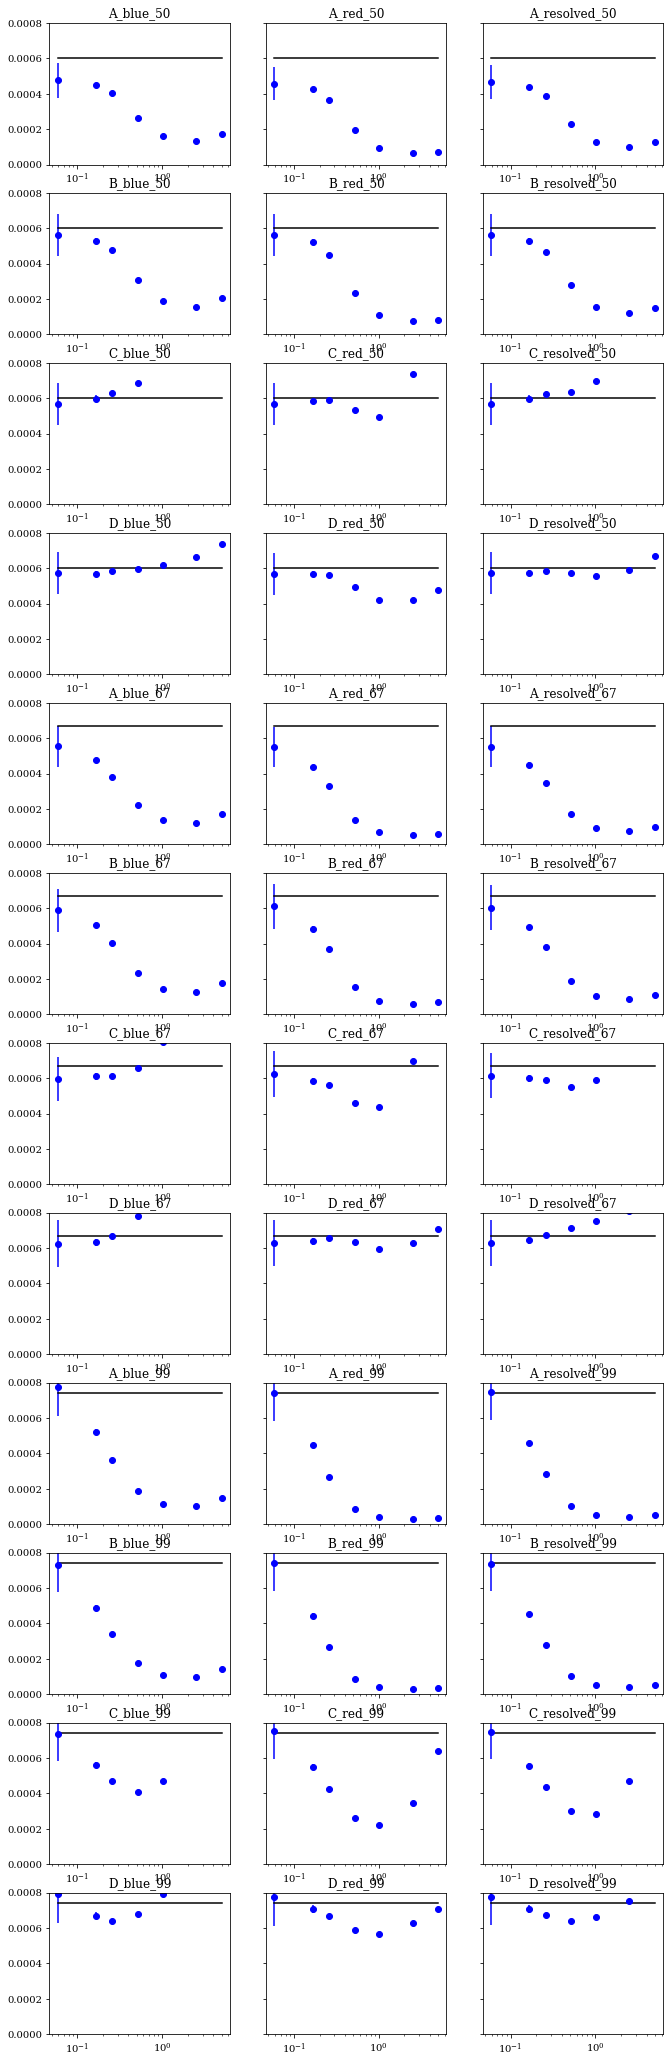

In [30]:
# getting model D values, snapshot 99
model = 'D'
snap = 99; snap_idx = snapshots.index(snap)

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
blue_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'red'
red_xpk = ds.getMatching(ip)[0].getData()

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'resolved'
res_xpk = ds.getMatching(ip)[0].getData()

k_dict[snap] = []

for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            
            # blue
            key = get_key(model, 'blue', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = blue_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(D_99_blue, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # red
            key = get_key(model, 'red', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = red_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(D_99_red, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
            
            # resolved
            key = get_key(model, 'resolved', snap)
            if key not in thi_dict:
                thi_dict[key] = []
            if key not in cov_dict:
                cov_dict[key] = []
            ydata = res_xpk[1][kmask]
            uncert = get_uncert(kmask, ydata * thi_snap)
            val, cov = curve_fit(D_99_resolved, xdata, ydata * thi_snap, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
            thi_dict[key].append(val[0])
            cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [31]:
pkl.dump(thi_dict, open('thi_fits.pkl', 'wb'))
pkl.dump(k_dict, open('k_fits.pkl', 'wb'))
pkl.dump(cov_dict, open('cov_fits.pkl', 'wb'))